<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TP 3 - Signal Detection Theory and Bayesian Inference</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TP)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objectives
The objective of this TP is twofold:

1- Get familiar with model comparison/falsification with the Stimulus Detection Task
- Implement the High-threshold theory (HTT) model
- Implement the Signal Detection Theory (SDT) model
- Use the Receiver Operating Characteristic (ROC) curve to display the models

2- Understand the basic principles behind bayesian inference
- Concepts of prior, likelihood, and posterior
- Generative model
- Bayes' rule
- Bayesian inference

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math

%reload_ext autoreload
%autoreload 2

# 1- Signal Detection Theory

## Data Loading and Cleaning
Here we load the data from `data.csv`.

In [2]:
raw_data = pd.read_csv('data.csv')
raw_data

,participant,block,trial,stim,wght,resp,reversal,isswitch,isrepeat
0,1,2,1,1,3,1.0,0,NaN,NaN
1,1,2,2,1,3,1.0,0,0.0,1.0
2,1,2,3,1,1,1.0,0,0.0,1.0
3,1,2,4,1,2,1.0,0,0.0,1.0
4,1,2,5,1,1,1.0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
19195,30,16,76,-1,1,1.0,0,1.0,0.0
19196,30,16,77,-1,1,1.0,0,0.0,1.0
19197,30,16,78,-1,2,-1.0,0,1.0,0.0
19198,30,16,79,-1,2,-1.0,0,0.0,1.0


We clean the data: the NaN (*Not a Number*) values are dropped, and we cast all numerical values as integers.

In [3]:
# Todo: Question: les NAN je les drop tout simplement ?

In [4]:
data = raw_data.dropna().astype(int)
data

,participant,block,trial,stim,wght,resp,reversal,isswitch,isrepeat
1,1,2,2,1,3,1,0,0,1
2,1,2,3,1,1,1,0,0,1
3,1,2,4,1,2,1,0,0,1
4,1,2,5,1,1,1,0,0,1
5,1,2,6,1,2,1,0,0,1
...,...,...,...,...,...,...,...,...,...
19195,30,16,76,-1,1,1,0,1,0
19196,30,16,77,-1,1,1,0,0,1
19197,30,16,78,-1,2,-1,0,1,0
19198,30,16,79,-1,2,-1,0,0,1


## Data visualization
### A) Data from one participant
#### Contingency Table
Make a contingency table like the one illustrated in the figure to display the hits (H), misses (M), false alarms (FA) and correct rejections (CR).
Use the data of participant 1, block 2.
<img src="images/contingency_table.png" style="height: 200px; margin-left: 10px;" />

📝 Complete the `contingency_statistics` function, which takes in a DataFrame that contains a 'stim' and a 'resp' column and returns the hits, false alarms, misses, correct rejections. In the dataset: 
- 1 codes for the presence of signal in the 'stim' column, and for a 'yes' response in the 'resp' column
- -1 codes for only noise in the 'stim' column, and for a 'no' response in the 'resp' column.

In [5]:
def contingency_statistics(data: pd.DataFrame):
    stimuli = data['stim'] # Contains values among {-1, 1} (noise, signal+noise)
    responses = data['resp'] # Contains values among {-1, 1} (no, yes)
    
    # Your code here
    hits = ...
    fa = ...
    miss = ...
    cr = ...

    return hits, fa, miss, cr

In [6]:
# Solution
def contingency_statistics(data: pd.DataFrame):
    stimuli = data['stim']
    resp = data['resp']

    correct = stimuli == resp

    hits = ((stimuli == 1) & correct).sum()
    fa = ((stimuli == -1) & ~correct).sum()
    miss = ((stimuli == 1) & ~correct).sum()
    cr = ((stimuli == -1) & correct).sum()

    hr = hits / (stimuli == 1).sum()
    far = fa / (stimuli == -1).sum()
    mr = miss / (stimuli == 1).sum()
    crr = cr / (stimuli == -1).sum()

    return hr, far, mr, crr

Test your function on the first participant, block 2. You should obtain hr=0.75, far=0.108, mr=0.25, cr=0.89.

In [7]:
hr, far, mr, cr = contingency_statistics(data.query("participant == 1 and block == 2"))
hr, far, mr, cr

(np.float64(0.75),
 np.float64(0.10810810810810811),
 np.float64(0.25),
 np.float64(0.8918918918918919))

Plot your rates in a contingency matrix like the one shown in the question above

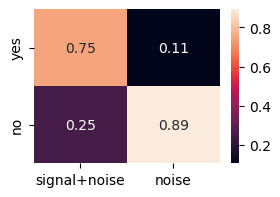

In [8]:
def plot_contingency_matrix(hits, fa, miss, cr):
    plt.figure(figsize=(3, 2))
    sns.heatmap([[hits, fa],
                 [miss, cr]], annot=True,
                xticklabels=['signal+noise', 'noise'], yticklabels=['yes', 'no'])
    plt.plot()

plot_contingency_matrix(hr, far, mr, cr)

In [28]:
# Todo: On normalise ou pas? On pourrait juste montrer les contingences en entiers, puis ensuite calculer HR et FAR séparément.

### B) Data from all participants

#### Contingency statistics for each participant

In [10]:
# Todo: calculer pour chaque bloc ou chaque participant ? (je dirais participant)

In [11]:
hit_rates = []
false_alarm_rates = []
for _, participant_data in data.groupby('participant'):
    hr, far, mr, cr = contingency_statistics(participant_data)
    hit_rates.append(hr)
    false_alarm_rates.append(far)

#### Plot 
📝 In a scatter plot, show the false alarm rates of participants as a function of their hit rates and:
- Place the false alarm rate (FAR) on the x axis, and the hit rate (HR) on the y axis.
- Set the x and y axis limits to (0, 1)

In [12]:
def plot_hr_far(hit_rates, false_alarm_rates):
    ...

plot_hr_far(hit_rates, false_alarm_rates)

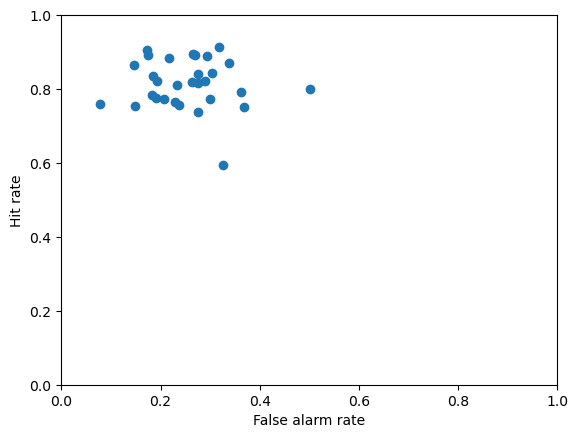

In [13]:
def plot_hr_far(hit_rates, false_alarm_rates):
    plt.scatter(false_alarm_rates, hit_rates)
    plt.xlabel('False alarm rate')
    plt.ylabel('Hit rate')
    plt.xlim(0, 1)
    plt.ylim(0, 1)

plot_hr_far(hit_rates, false_alarm_rates)

## Theory #1: High-threshold theory
Before using the signal detection theory, we will first start with the theory that was popular just before, **high-threshold theory**. This theory characterizes each participant by considering that he/she has a distinct **detection sensitivity**. This means that we assume that a signal $s$ will trigger an (unobserved) sensory response $r(s)$. Then, if the response is higher than the detection sensitivity $p$ ($r(s) > p$), the participant will report that they detected a stimulus. HTT gives the following formula to estimate $p$ as a function of the hit rate (HR) and the false alarm rate (FAR):
- **Detection sensitivity**: $p = \frac{\text{HR} - \text{FAR}}{1-\text{FAR}}$

And what if the stimulus response is lower than the sensitivity threshold $p$? Then we assume that the participant guesses and reports the presence of a stimulus at a rate given by the **detection criterion**, which is equivalent to the false alarm rate (FAR):
- **Detection criterion**: $g = \text{FAR}$

In [41]:
#TODO: Quelle est la logique derrière ces formules ?
# C'est bizarre que p dépend de g (FAR)

📝 Fill the `compute_htt` function, which computes $p$ and $g$ based on the hit rate and false alarm rate of a participant.

In [15]:
def compute_htt(hit_rate, false_alarm_rate):
    p = ...
    g = ...
    return p, g

In [16]:
# Solution
def compute_htt(hit_rate, false_alarm_rate):
    p = (hit_rate - false_alarm_rate) / (1 - false_alarm_rate)
    g = false_alarm_rate
    return p, g

In [17]:
p, g = compute_htt(np.array(hit_rates), np.array(false_alarm_rates))

#### HTT ROC Curve
Plot the ROC curve of your HTT model. The ROC curve is the

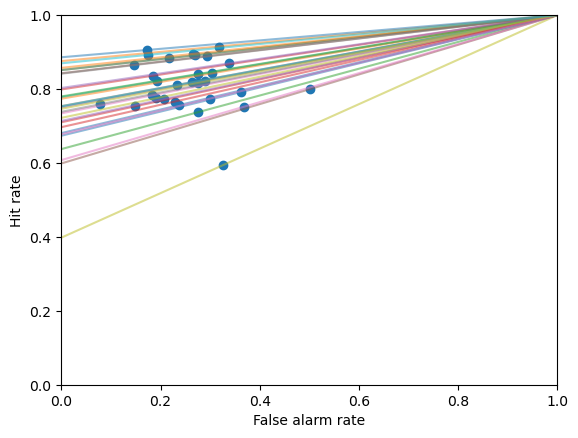

In [40]:
def plot_htt_model(hit_rates, false_alarm_rates, p):
    plot_hr_far(hit_rates, false_alarm_rates)
    for p_indiv in p:
        far = np.linspace(0, 1, 100)
        hr = (1 - p_indiv) * far + p_indiv
        plt.plot(far, hr, alpha=0.5)
    plt.show()

plot_htt_model(hit_rates, false_alarm_rates, p)

In [32]:
# ?? Ça n'a pas de sens de faire une ROC curve pour plusieurs participants. Je ne peux faire de courbe que pour un p fixé.

## Theory #2: Signal Detection Theory
Signal Detection Theory then replaced High-Threshold Theory as a reference model for stimulus detection. This theory also uses a **detection sensitivity** and a detection criterion.
- **Detection sensitivity**: $d' = \frac{\mu_s - \mu_n}{\sigma_n}$
- **Detection criterion**: $c = \frac{z(\text{HR}) + z(\text{FAR})}{2}$

In [19]:
# Todo: Je comprends pas trop les concepts de detection sensitivity \ criterion. Ça ne s'aligne pas avec ceux de la HTT.

In [ ]:
mu_s = ...
mu_n = ...

d = (mu_s - mu_n) / sigma_n
c = ...

# 2- Bayesian Inference
Bayes' rule is crucial for understanding perception, and we will use it throughout the course. In this section, we will see how to use it on a simple example, from the book [*Bayesian Models of Perception and Action*](https://www.cns.nyu.edu/malab/bayesianbook.html)$^{(1)}$. 

We will examine the perception of wetness of a surface, in this case a floor.
- We consider that the floor can have two possible states: **wet** or **dry**
- We can make two possible observations when looking at the floor: it can be **shiny** or **not shiny**.

The figure below shows a shiny floor, and how this observation can transform our prior belief about the usual wetness of that floor, into an updated belief, considering what we observe. We will break down the notions of **prior**, **posterior** and **likelihood** in this exercise.
<img src="images/bayesian_example.png" style="height: 200px; margin-left: 10px;" />

## Step 1: Generative model

The first step of Bayesian modeling is the **generative model**, which represents the statistical structure of the world and the observations. As mentioned above, we consider in our example two possible world states, each of which can generate two possible observations. In the generative model, we need to specify the probability distributions of all variables of the problem.

We therefore assume that, from experience, the observer considers that:
- **Base rate:** In general, the floor has a 10% probability of being wet.
- **Conditional probability:** If it is wet, it has a 80% probabililty of being shiny.
- **Conditional probability:** If it is dry, it has a 40% probability of being shiny.

The figure below illustrates the generative model. The conditional probabilities are left for you to deduce.

<img src="images/generative_model.png" style="height: 200px; margin-left: 10px;" />

📝 Define the `priors` of each state of the world (regardless of the observation):
- $p(\text{wet})$
- $p(\text{dry})$

In [20]:
priors = {
    'wet': ...,
    'dry': ...
}

In [21]:
# Solution
priors = {
    'wet': 0.1,
    'dry': 0.9
}

📝 Define the `likelihoods` of each observation, under each hypothesis. The values that you need to enter in this dictionary are, in order:
- $p(\text{shiny}|\text{wet})$
- $p(\text{not shiny}|\text{wet})$
- $p(\text{shiny}|\text{dry})$
- $p(\text{not shiny}|\text{dry})$

In [22]:
## TODO: (détail) est-ce que je peux parler de vraisemblance à l'étape du modèle génératif ?

In [23]:
likelihoods = {
    'wet': {
        'shiny': ...,
        'not_shiny': ...
    },
    'dry': {
        'shiny': ...,
        'not_shiny': ...
    }
}

In [24]:
# Solution
likelihoods = {
    'wet': {
        'shiny': 0.8,
        'not_shiny': 0.2
    },
    'dry': {
        'shiny': 0.4,
        'not_shiny': 0.6
    }
}

## Step 2: Inference

Now that we have defined the alterative hypotheses on the state of the floor, your priors for each ot them and the likelihoods of each possible observation under each hypothesis, let's perform **inference**.  

**Obsevation:** Suppose that the observer **sees the floor as shiny**. What can they infer in terms of its probability of being wet?

<img src="images/inference.png" style="height: 150px; margin-left: 10px;" />

We use Bayes' rule as a formula to update the prior belief and take into consideration the observation:

$$
\underbrace{P(H|\text{obs})}_\text{posterior} = \frac{\overbrace{p(\text{obs|H})}^\text{likelihood}\overbrace{p(H)}^\text{prior}}{p(\text{obs})}
$$

You'll notice that we haven't talked about the denominator of this formula yet: $p(\text{obs})$. It is necessary to normalize the posterior and make it a proper probability. In our case, $p(\text{shiny}$ represents the probability of seeing a shiny floor in all possible world states. I let you think about how to calculate this value, and don't hesitate to discuss it with your neighbor. 

📝 Complete the `bayesian_inference` function below. It takes as an input an `observation`, as well as the `priors` and `likelihoods` dictionaries that we have defined previously. It then computes and returns the `posteriors` dictionary. The latter has exactly the same format as the `priors`. 

In [25]:
def bayesian_inference(observation: str, priors: dict, likelihoods: dict) -> dict:
    posteriors = {}   # Create the output dictionary
    hypotheses = priors.keys()  # The keys of the priors dictionary are ['wet', 'dry']

    # Compute a posterior probability for each hypothesis
    for hypothesis in hypotheses:
        # Your code here
        ...

        posteriors[hypotesis] = ...
        
    return posteriors

In [26]:
# Solution
def bayesian_inference(observation: str, priors: dict, likelihoods: dict) -> dict:
    posteriors = {}
    hypotheses = priors.keys()
    
    for hypothesis in hypotheses:
        protoposterior = likelihoods[hypothesis][observation] * priors[hypothesis]
        normalization = sum(likelihoods[hyp][observation] * priors[hyp] 
                            for hyp in hypotheses)
        posteriors[hypothesis] = protoposterior / normalization
    return posteriors



Imagine that you see the floor as shiny, just as 

Call your bayesian_inference function with the hypothesis that you want to evaluate.  
Note: The `priors` and `likelihoods` dictionaries

In [27]:
observation = 'shiny'

posteriors = bayesian_inference(observation, priors, likelihoods)

# Unit tests
assert isinstance(posteriors, dict), "Your posterior should be a dictionary"
assert set(posteriors.keys()) == {'wet', 'dry'}, "Your posteriors dictionary should have the same format as the priors."
assert math.isclose(posteriors['wet'], 0.182, abs_tol=0.001), "Incorrect posterior value for the 'wet' hypothesis"
assert math.isclose(posteriors['dry'], 0.818, abs_tol=0.001), "Incorrect posterior value for the 'dry' hypothesis"
print("OK 👌")

OK 👌


## Bonus: Bayesian Inference with continuous variables
You can do this part if you were already familiar with bayesian probability theory and you would like to go further.

### References: 
Ma, W. J., Kording, K. P., & Goldreich, D. (2023). Bayesian Models of Perception and Action: An Introduction. MIT press.  
Available https://www.cns.nyu.edu/malab/bayesianbook.html
